# HIIT Session Scoring Project

## Overview
This project processes HRM files and scores HIIT training sessions based on whether the participant reaches target heart rate zones during high-intensity intervals.

The solution is implemented as a modular and reusable pipeline that can be applied to new HRM datasets without modification.

---

## Project Structure
- hiit_session_scoring_pipeline.ipynb → main pipeline  
- src/ → modular implementation  
- outputs/ → CSV results  
- reports/ → project report  
- README.md → project overview and usage  

---

## Key Results
- Total sessions: 31  
- Valid sessions: 24  
- Invalid sessions: 7  

Score distribution (valid sessions):
- Score 1: 2  
- Score 2: 6  
- Score 3: 8  
- Score 4: 6  
- Score 5: 2  

---

## Method Summary
Parse → Validate → Clean → Convert → Detect Peaks → Compute Zone → Score  

---

## Output
Main fields:
- file_name  
- date  
- week  
- score  
- is_valid  
- reason  

---

## Notes
The full implementation is modular (src/) and results are available in the outputs folder.  
See the report for detailed methodology.

# 1. Project Setup

In this section, we create the project directory structure and prepare the environment.

In [ ]:
import os

# Define project directories
PROJECT_DIR = "/content/hiit_project"
RAW_DATA_DIR = os.path.join(PROJECT_DIR, "data", "raw")
OUTPUT_DIR = os.path.join(PROJECT_DIR, "outputs")
SRC_DIR = os.path.join(PROJECT_DIR, "src")
REPORT_DIR = os.path.join(PROJECT_DIR, "reports")

# Create directories if they do not exist
for directory in [PROJECT_DIR, RAW_DATA_DIR, OUTPUT_DIR, SRC_DIR, REPORT_DIR]:
    os.makedirs(directory, exist_ok=True)

print("Project directories created successfully.")
print(f"Project directory: {PROJECT_DIR}")

Project directories created successfully.
Project directory: /content/hiit_project


In [ ]:
# Global configuration parameters

PATIENT_ID = "STUDY-042"
PATIENT_HRMAX = 165
FIRST_SESSION_DATE = "20240408"
TOTAL_SCHEDULED_SESSIONS = 24

# 2. Data Loading

We load and extract the HRM files and collect all file paths for processing.

In [ ]:
import zipfile

# Path to the uploaded zip file
ZIP_PATH = "/content/files.zip"

# Extract all files into the raw data directory
with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(RAW_DATA_DIR)

print("Zip file extracted successfully.")

Zip file extracted successfully.


In [ ]:
# Collect all HRM files recursively
hrm_files = []

for root, dirs, files in os.walk(RAW_DATA_DIR):
    for file in files:
        if file.lower().endswith(".hrm"):
            full_path = os.path.join(root, file)
            hrm_files.append(full_path)

print(f"Total HRM files found: {len(hrm_files)}")

# Print the first 10 HRM files
for file_path in hrm_files[:10]:
    print(file_path)

Total HRM files found: 31
/content/hiit_project/data/raw/files/package_for_candidate/sample_data/HRV_20240613_1100.hrm
/content/hiit_project/data/raw/files/package_for_candidate/sample_data/HRV_20240624_1145.hrm
/content/hiit_project/data/raw/files/package_for_candidate/sample_data/HRV_20240411_0815.hrm
/content/hiit_project/data/raw/files/package_for_candidate/sample_data/HRV_20240509_1130.hrm
/content/hiit_project/data/raw/files/package_for_candidate/sample_data/HRV_20240411_0912.hrm
/content/hiit_project/data/raw/files/package_for_candidate/sample_data/HRV_20240425_0830.hrm
/content/hiit_project/data/raw/files/package_for_candidate/sample_data/HRV_20240527_1115.hrm
/content/hiit_project/data/raw/files/package_for_candidate/sample_data/HRV_20240617_1145.hrm
/content/hiit_project/data/raw/files/package_for_candidate/sample_data/HRV_20240603_1030.hrm
/content/hiit_project/data/raw/files/package_for_candidate/sample_data/HRV_20240610_0845.hrm


In [ ]:
# Inspect one HRM file to understand its structure

sample_file = hrm_files[0]

print(f"Sample file: {sample_file}")
print("-" * 80)

with open(sample_file, "r", encoding="utf-8", errors="ignore") as file:
    lines = file.readlines()

# Print the first 40 lines
for i, line in enumerate(lines[:40]):
    print(f"{i+1}: {line.strip()}")

Sample file: /content/hiit_project/data/raw/files/package_for_candidate/sample_data/HRV_20240613_1100.hrm
--------------------------------------------------------------------------------
1: [Params]
2: Version=106
3: Monitor=99
4: SMode=00000000
5: Date=20240613
6: StartTime=11:00:00.0
7: Length=00:00:00.0
8: Interval=238
9: Upper1=0
10: Lower1=0
11: Upper2=0
12: Lower2=0
13: Upper3=0
14: Lower3=0
15: Timer1=00:00
16: Timer2=00:00
17: Timer3=00:00
18: ActiveLimit=0
19: MaxHR=165
20: RestHR=
21: StartDelay=0
22: VO2max=
23: Weight=78
24: 
25: [Note]
26: acentas Heart Rate Variability Data
27: [HRZones]
28: 165
29: 148
30: 132
31: 115
32: 99
33: 0
34: 0
35: 0
36: 0
37: 0
38: 0
39: 0
40: 


In [ ]:
# Find the HRData section and inspect the first RR interval values

hrdata_index = None

for i, line in enumerate(lines):
    if line.strip() == "[HRData]":
        hrdata_index = i
        break

if hrdata_index is None:
    print("HRData section not found.")
else:
    print(f"HRData section found at line: {hrdata_index + 1}")
    print("-" * 80)

    # Print the first 20 lines after [HRData]
    for j, line in enumerate(lines[hrdata_index + 1 : hrdata_index + 21]):
        print(f"{hrdata_index + j + 2}: {line.strip()}")

HRData section found at line: 41
--------------------------------------------------------------------------------
42: 932
43: 940
44: 940
45: 974
46: 909
47: 898
48: 898
49: 961
50: 914
51: 921
52: 902
53: 930
54: 896
55: 959
56: 948
57: 976
58: 956
59: 897
60: 916
61: 921


In [ ]:
# Check how many lines exist after the HRData section

lines_after_hrdata = lines[hrdata_index + 1:]

print(f"Total lines in file: {len(lines)}")
print(f"Lines after HRData: {len(lines_after_hrdata)}")

print("-" * 80)
print("First 10 raw lines after HRData:")

for i, line in enumerate(lines_after_hrdata[:10], start=1):
    print(f"{i}: {repr(line)}")

Total lines in file: 1981
Lines after HRData: 1940
--------------------------------------------------------------------------------
First 10 raw lines after HRData:
1: '932\n'
2: '940\n'
3: '940\n'
4: '974\n'
5: '909\n'
6: '898\n'
7: '898\n'
8: '961\n'
9: '914\n'
10: '921\n'


In [ ]:
# Count valid numeric RR interval values after HRData

valid_rr_values = []

for line in lines_after_hrdata:
    line = line.strip()

    if line == "":
        continue

    try:
        valid_rr_values.append(int(line))
    except ValueError:
        pass

print(f"Valid RR interval values: {len(valid_rr_values)}")
print(f"First 10 valid RR values: {valid_rr_values[:10]}")

Valid RR interval values: 1940
First 10 valid RR values: [932, 940, 940, 974, 909, 898, 898, 961, 914, 921]


In [ ]:
# Find HRM files that contain valid RR interval values

valid_file_candidates = []

for file_path in hrm_files:
    with open(file_path, "r", encoding="utf-8", errors="ignore") as file:
        file_lines = file.readlines()

    # Find HRData section
    hrdata_index = None
    for i, line in enumerate(file_lines):
        if line.strip() == "[HRData]":
            hrdata_index = i
            break

    # Skip files without HRData
    if hrdata_index is None:
        continue

    # Extract numeric RR values
    rr_values = []

    for line in file_lines[hrdata_index + 1:]:
        line = line.strip()

        if line == "":
            continue

        try:
            rr_values.append(int(line))
        except ValueError:
            continue

    if len(rr_values) > 0:
        valid_file_candidates.append((file_path, len(rr_values)))

print(f"Files with at least one RR value: {len(valid_file_candidates)}")
print("-" * 80)

for file_path, rr_count in valid_file_candidates[:10]:
    print(f"{rr_count} RR values | {file_path}")

Files with at least one RR value: 27
--------------------------------------------------------------------------------
1940 RR values | /content/hiit_project/data/raw/files/package_for_candidate/sample_data/HRV_20240613_1100.hrm
1846 RR values | /content/hiit_project/data/raw/files/package_for_candidate/sample_data/HRV_20240624_1145.hrm
1854 RR values | /content/hiit_project/data/raw/files/package_for_candidate/sample_data/HRV_20240411_0815.hrm
1759 RR values | /content/hiit_project/data/raw/files/package_for_candidate/sample_data/HRV_20240509_1130.hrm
1929 RR values | /content/hiit_project/data/raw/files/package_for_candidate/sample_data/HRV_20240425_0830.hrm
1866 RR values | /content/hiit_project/data/raw/files/package_for_candidate/sample_data/HRV_20240527_1115.hrm
1816 RR values | /content/hiit_project/data/raw/files/package_for_candidate/sample_data/HRV_20240617_1145.hrm
2062 RR values | /content/hiit_project/data/raw/files/package_for_candidate/sample_data/HRV_20240603_1030.hrm
18

In [ ]:
%%writefile /content/hiit_project/src/hrm_parser.py

from pathlib import Path
from typing import Dict, List, Optional, Any


def parse_metadata(lines: List[str]) -> Dict[str, Optional[str]]:
    """
    Extract metadata from the [Params] section of an HRM file.

    Parameters
    ----------
    lines : List[str]
        Raw lines from the HRM file.

    Returns
    -------
    Dict[str, Optional[str]]
        Dictionary containing metadata fields such as date, start time, and max HR.
    """
    metadata = {}

    for line in lines:
        line = line.strip()

        # Stop reading metadata when another section starts
        if line.startswith("[") and line != "[Params]":
            break

        if "=" in line:
            key, value = line.split("=", 1)
            metadata[key.strip()] = value.strip() if value.strip() != "" else None

    return metadata


def extract_rr_intervals(lines: List[str]) -> List[int]:
    """
    Extract RR interval values from the [HRData] section.

    Parameters
    ----------
    lines : List[str]
        Raw lines from the HRM file.

    Returns
    -------
    List[int]
        RR interval values in milliseconds.
    """
    rr_intervals = []
    in_hrdata_section = False

    for line in lines:
        line = line.strip()

        if line == "[HRData]":
            in_hrdata_section = True
            continue

        if in_hrdata_section:
            if line == "":
                continue

            try:
                rr_intervals.append(int(line))
            except ValueError:
                # Ignore non-numeric lines in the HRData section
                continue

    return rr_intervals


def read_hrm_file(file_path: str) -> Dict[str, Any]:
    """
    Read an HRM file and extract metadata and RR intervals.

    Parameters
    ----------
    file_path : str
        Path to the HRM file.

    Returns
    -------
    Dict[str, Any]
        Parsed HRM content including file name, metadata, and RR intervals.
    """
    file_path = Path(file_path)

    with open(file_path, "r", encoding="utf-8", errors="ignore") as file:
        lines = file.readlines()

    metadata = parse_metadata(lines)
    rr_intervals = extract_rr_intervals(lines)

    return {
        "file_name": file_path.name,
        "file_path": str(file_path),
        "metadata": metadata,
        "rr_intervals": rr_intervals,
        "rr_count": len(rr_intervals),
    }

Writing /content/hiit_project/src/hrm_parser.py


# 3. HRM Parsing

We parse HRM files to extract metadata and RR interval values.

In [ ]:
import sys

# Add the src directory to Python path
sys.path.append("/content/hiit_project/src")

from hrm_parser import read_hrm_file

# Select a valid-looking sample file
sample_valid_file = valid_file_candidates[0][0]

parsed = read_hrm_file(sample_valid_file)

print("File name:", parsed["file_name"])
print("RR count:", parsed["rr_count"])
print("Metadata:")
print(parsed["metadata"])
print("First 10 RR intervals:")
print(parsed["rr_intervals"][:10])

File name: HRV_20240613_1100.hrm
RR count: 1940
Metadata:
{'Version': '106', 'Monitor': '99', 'SMode': '00000000', 'Date': '20240613', 'StartTime': '11:00:00.0', 'Length': '00:00:00.0', 'Interval': '238', 'Upper1': '0', 'Lower1': '0', 'Upper2': '0', 'Lower2': '0', 'Upper3': '0', 'Lower3': '0', 'Timer1': '00:00', 'Timer2': '00:00', 'Timer3': '00:00', 'ActiveLimit': '0', 'MaxHR': '165', 'RestHR': None, 'StartDelay': '0', 'VO2max': None, 'Weight': '78'}
First 10 RR intervals:
[932, 940, 940, 974, 909, 898, 898, 961, 914, 921]


In [ ]:
%%writefile /content/hiit_project/src/validation.py

from typing import Dict, Any


MIN_RR_COUNT = 300


def validate_session(parsed_session: Dict[str, Any], min_rr_count: int = MIN_RR_COUNT) -> Dict[str, Any]:
    """
    Validate whether a parsed HRM session contains enough usable RR interval data.

    Parameters
    ----------
    parsed_session : Dict[str, Any]
        Parsed HRM session returned by read_hrm_file().
    min_rr_count : int
        Minimum number of RR intervals required to treat a session as valid.

    Returns
    -------
    Dict[str, Any]
        Validation result containing validity status and reason.
    """
    rr_count = parsed_session.get("rr_count", 0)

    if rr_count == 0:
        return {
            "is_valid": False,
            "reason": "invalid_no_rr_data"
        }

    if rr_count < min_rr_count:
        return {
            "is_valid": False,
            "reason": "invalid_too_short"
        }

    return {
        "is_valid": True,
        "reason": "valid"
    }

Writing /content/hiit_project/src/validation.py


# 4. Data Validation

We validate each session to identify usable data and exclude invalid or incomplete sessions.

In [ ]:
from validation import validate_session

validation_result = validate_session(parsed)

print(validation_result)

{'is_valid': True, 'reason': 'valid'}


In [ ]:
from hrm_parser import read_hrm_file
from validation import validate_session

validation_summary = []

# Validate all HRM files
for file_path in hrm_files:
    parsed_session = read_hrm_file(file_path)
    validation_result = validate_session(parsed_session)

    validation_summary.append({
        "file_name": parsed_session["file_name"],
        "file_path": parsed_session["file_path"],
        "rr_count": parsed_session["rr_count"],
        "is_valid": validation_result["is_valid"],
        "reason": validation_result["reason"],
    })

# Print validation results
for row in validation_summary:
    print(
        row["file_name"],
        "| RR count:",
        row["rr_count"],
        "| valid:",
        row["is_valid"],
        "| reason:",
        row["reason"]
    )

HRV_20240613_1100.hrm | RR count: 1940 | valid: True | reason: valid
HRV_20240624_1145.hrm | RR count: 1846 | valid: True | reason: valid
HRV_20240411_0815.hrm | RR count: 1854 | valid: True | reason: valid
HRV_20240509_1130.hrm | RR count: 1759 | valid: True | reason: valid
HRV_20240411_0912.hrm | RR count: 0 | valid: False | reason: invalid_no_rr_data
HRV_20240425_0830.hrm | RR count: 1929 | valid: True | reason: valid
HRV_20240527_1115.hrm | RR count: 1866 | valid: True | reason: valid
HRV_20240617_1145.hrm | RR count: 1816 | valid: True | reason: valid
HRV_20240603_1030.hrm | RR count: 2062 | valid: True | reason: valid
HRV_20240610_0845.hrm | RR count: 1822 | valid: True | reason: valid
HRV_20240523_1030.hrm | RR count: 2037 | valid: True | reason: valid
HRV_20240613_0847.hrm | RR count: 0 | valid: False | reason: invalid_no_rr_data
HRV_20240429_0845.hrm | RR count: 2048 | valid: True | reason: valid
HRV_20240408_0830.hrm | RR count: 1972 | valid: True | reason: valid
HRV_20240530

In [ ]:
import pandas as pd

validation_df = pd.DataFrame(validation_summary)

print(validation_df["reason"].value_counts())
validation_df.head()

reason
valid                 24
invalid_no_rr_data     4
invalid_too_short      3
Name: count, dtype: int64


,file_name,file_path,rr_count,is_valid,reason
0,HRV_20240613_1100.hrm,/content/hiit_project/data/raw/files/package_f...,1940,True,valid
1,HRV_20240624_1145.hrm,/content/hiit_project/data/raw/files/package_f...,1846,True,valid
2,HRV_20240411_0815.hrm,/content/hiit_project/data/raw/files/package_f...,1854,True,valid
3,HRV_20240509_1130.hrm,/content/hiit_project/data/raw/files/package_f...,1759,True,valid
4,HRV_20240411_0912.hrm,/content/hiit_project/data/raw/files/package_f...,0,False,invalid_no_rr_data


In [ ]:
%%writefile /content/hiit_project/src/rr_cleaning.py

from typing import List, Dict, Any
import numpy as np


MIN_RR_MS = 300
MAX_RR_MS = 2000
MISSED_BEAT_RATIO = 1.8


def clean_rr_intervals(
    rr_intervals: List[int],
    min_rr_ms: int = MIN_RR_MS,
    max_rr_ms: int = MAX_RR_MS,
    missed_beat_ratio: float = MISSED_BEAT_RATIO
) -> Dict[str, Any]:
    """
    Clean RR interval data by removing unrealistic values and correcting likely missed beats.

    Parameters
    ----------
    rr_intervals : List[int]
        Raw RR interval values in milliseconds.
    min_rr_ms : int
        Minimum physiologically plausible RR interval.
    max_rr_ms : int
        Maximum physiologically plausible RR interval.
    missed_beat_ratio : float
        Ratio used to identify likely missed beats compared with the previous RR interval.

    Returns
    -------
    Dict[str, Any]
        Cleaned RR intervals and cleaning statistics.
    """
    cleaned_rr = []
    removed_count = 0
    corrected_missed_beats = 0

    previous_valid_rr = None

    for rr in rr_intervals:
        # Remove physiologically implausible RR values
        if rr < min_rr_ms or rr > max_rr_ms:
            removed_count += 1
            continue

        # Correct likely missed beats by splitting unusually long intervals
        if previous_valid_rr is not None and rr > missed_beat_ratio * previous_valid_rr:
            half_rr = rr / 2

            if min_rr_ms <= half_rr <= max_rr_ms:
                cleaned_rr.extend([half_rr, half_rr])
                corrected_missed_beats += 1
                previous_valid_rr = half_rr
                continue

        cleaned_rr.append(rr)
        previous_valid_rr = rr

    return {
        "cleaned_rr": cleaned_rr,
        "raw_count": len(rr_intervals),
        "cleaned_count": len(cleaned_rr),
        "removed_count": removed_count,
        "corrected_missed_beats": corrected_missed_beats,
    }


def rr_to_heart_rate(rr_intervals: List[float]) -> List[float]:
    """
    Convert RR intervals in milliseconds to heart rate in beats per minute.

    Parameters
    ----------
    rr_intervals : List[float]
        RR interval values in milliseconds.

    Returns
    -------
    List[float]
        Heart rate values in beats per minute.
    """
    rr_array = np.array(rr_intervals, dtype=float)

    return (60000 / rr_array).tolist()

Writing /content/hiit_project/src/rr_cleaning.py


# 5. RR Cleaning and Heart Rate Conversion

We clean RR intervals by removing artifacts and correcting potential missed beats, then convert them into heart rate values.

In [ ]:
from rr_cleaning import clean_rr_intervals, rr_to_heart_rate

cleaning_result = clean_rr_intervals(parsed["rr_intervals"])
heart_rate = rr_to_heart_rate(cleaning_result["cleaned_rr"])

print("Raw RR count:", cleaning_result["raw_count"])
print("Cleaned RR count:", cleaning_result["cleaned_count"])
print("Removed RR count:", cleaning_result["removed_count"])
print("Corrected missed beats:", cleaning_result["corrected_missed_beats"])
print("First 10 heart rate values:")
print(heart_rate[:10])

Raw RR count: 1940
Cleaned RR count: 1939
Removed RR count: 4
Corrected missed beats: 3
First 10 heart rate values:
[64.37768240343348, 63.829787234042556, 63.829787234042556, 61.60164271047228, 66.00660066006601, 66.815144766147, 66.815144766147, 62.43496357960458, 65.64551422319475, 65.14657980456026]


In [ ]:
# Analyze cleaning impact across all valid sessions

artifact_summary = []

for row in validation_summary:
    if not row["is_valid"]:
        continue

    parsed = read_hrm_file(row["file_path"])
    cleaning = clean_rr_intervals(parsed["rr_intervals"])

    artifact_summary.append({
        "file_name": parsed["file_name"],
        "raw_count": cleaning["raw_count"],
        "cleaned_count": cleaning["cleaned_count"],
        "removed": cleaning["removed_count"],
        "corrected": cleaning["corrected_missed_beats"]
    })

artifact_df = pd.DataFrame(artifact_summary)

print("Files with removed RR values:")
print((artifact_df["removed"] > 0).sum())

print("Files with corrected missed beats:")
print((artifact_df["corrected"] > 0).sum())

print("\nExamples:")
artifact_df[(artifact_df["removed"] > 0) | (artifact_df["corrected"] > 0)].head()

Files with removed RR values:
7
Files with corrected missed beats:
5

Examples:


,file_name,raw_count,cleaned_count,removed,corrected
0,HRV_20240613_1100.hrm,1940,1939,4,3
3,HRV_20240509_1130.hrm,1759,1757,2,0
7,HRV_20240603_1030.hrm,2062,2059,3,0
8,HRV_20240610_0845.hrm,1822,1824,0,2
11,HRV_20240408_0830.hrm,1972,1967,6,1


# 6. Heart Rate Visualization

We visualize the heart rate signal to inspect whether the session exhibits typical HIIT patterns with repeated high-intensity peaks.

In [ ]:
# Select a valid session for visualization

sample_valid_file = validation_df[
    validation_df["is_valid"] == True
]["file_path"].iloc[0]

parsed = read_hrm_file(sample_valid_file)

cleaning_result = clean_rr_intervals(parsed["rr_intervals"])
heart_rate = rr_to_heart_rate(cleaning_result["cleaned_rr"])

print("Selected file:", parsed["file_name"])
print("RR count:", parsed["rr_count"])
print("Heart rate values:", len(heart_rate))

Selected file: HRV_20240613_1100.hrm
RR count: 1940
Heart rate values: 1939


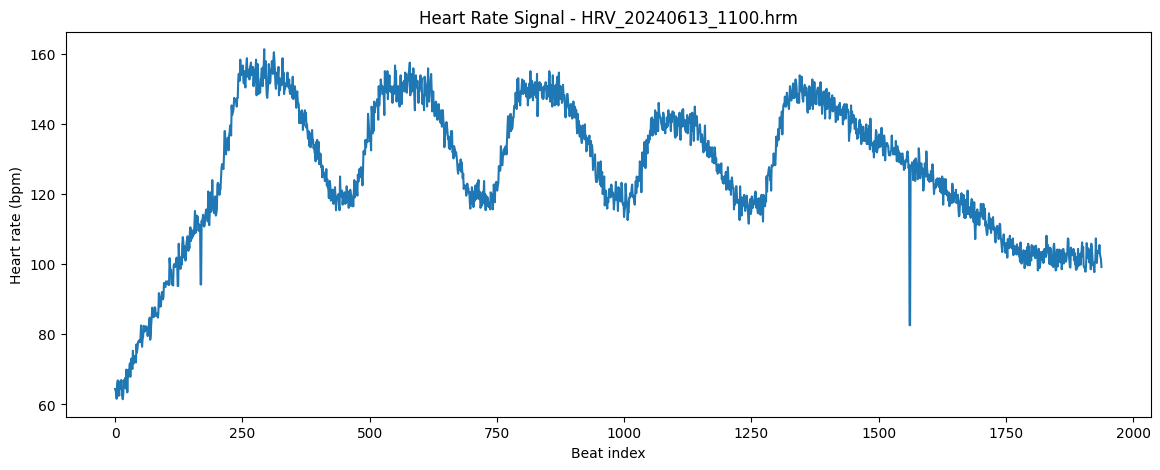

In [ ]:
import matplotlib.pyplot as plt

# Plot heart rate signal for the selected session
plt.figure(figsize=(14, 5))
plt.plot(heart_rate)

plt.title(f"Heart Rate Signal - {parsed['file_name']}")
plt.xlabel("Beat index")
plt.ylabel("Heart rate (bpm)")

plt.show()

# 7. Interval Detection

We detect high-intensity intervals by identifying prominent peaks in the heart rate signal.

In [ ]:
%%writefile /content/hiit_project/src/interval_detection.py

from typing import List, Dict, Any
import numpy as np
from scipy.signal import find_peaks


def smooth_signal(values: List[float], window_size: int = 15) -> np.ndarray:
    """
    Smooth a signal using a simple moving average.

    Parameters
    ----------
    values : List[float]
        Input signal values.
    window_size : int
        Size of the moving average window.

    Returns
    -------
    np.ndarray
        Smoothed signal.
    """
    values = np.array(values, dtype=float)

    if len(values) < window_size:
        return values

    kernel = np.ones(window_size) / window_size
    return np.convolve(values, kernel, mode="same")


def detect_hiit_peaks(
    heart_rate: List[float],
    expected_intervals: int = 5,
    min_distance: int = 180,
    prominence: float = 5.0,
    smoothing_window: int = 15
) -> Dict[str, Any]:
    """
    Detect high-intensity HIIT peaks from a heart rate signal.

    Parameters
    ----------
    heart_rate : List[float]
        Heart rate signal in beats per minute.
    expected_intervals : int
        Expected number of HIIT intervals.
    min_distance : int
        Minimum distance between peaks in beat indices.
    prominence : float
        Minimum peak prominence.
    smoothing_window : int
        Window size used for signal smoothing.

    Returns
    -------
    Dict[str, Any]
        Detected peak indices, peak heart rates, and smoothed signal.
    """
    smoothed_hr = smooth_signal(heart_rate, window_size=smoothing_window)

    peaks, properties = find_peaks(
        smoothed_hr,
        distance=min_distance,
        prominence=prominence
    )

    if len(peaks) > expected_intervals:
        # Select the most prominent peaks
        prominences = properties["prominences"]
        top_indices = np.argsort(prominences)[-expected_intervals:]
        peaks = peaks[top_indices]

    # Sort peaks chronologically
    peaks = np.sort(peaks)

    return {
        "peaks": peaks.tolist(),
        "peak_heart_rates": smoothed_hr[peaks].tolist(),
        "smoothed_heart_rate": smoothed_hr.tolist(),
        "num_peaks_detected": len(peaks)
    }

Writing /content/hiit_project/src/interval_detection.py


In [ ]:
from interval_detection import detect_hiit_peaks

peak_result = detect_hiit_peaks(heart_rate)

print("Number of peaks detected:", peak_result["num_peaks_detected"])
print("Peak indices:", peak_result["peaks"])
print("Peak heart rates:", peak_result["peak_heart_rates"])

Number of peaks detected: 5
Peak indices: [264, 575, 850, 1091, 1343]
Peak heart rates: [155.40371842000906, 152.43306728348415, 150.21185865630736, 141.5982728275621, 149.94706775319162]


In [ ]:
# Select a valid session for visualization

sample_valid_file = validation_df[
    validation_df["is_valid"] == True
]["file_path"].iloc[0]

parsed = read_hrm_file(sample_valid_file)

cleaning_result = clean_rr_intervals(parsed["rr_intervals"])
heart_rate = rr_to_heart_rate(cleaning_result["cleaned_rr"])

print("Selected file:", parsed["file_name"])
print("RR count:", parsed["rr_count"])
print("Heart rate values:", len(heart_rate))

Selected file: HRV_20240613_1100.hrm
RR count: 1940
Heart rate values: 1939


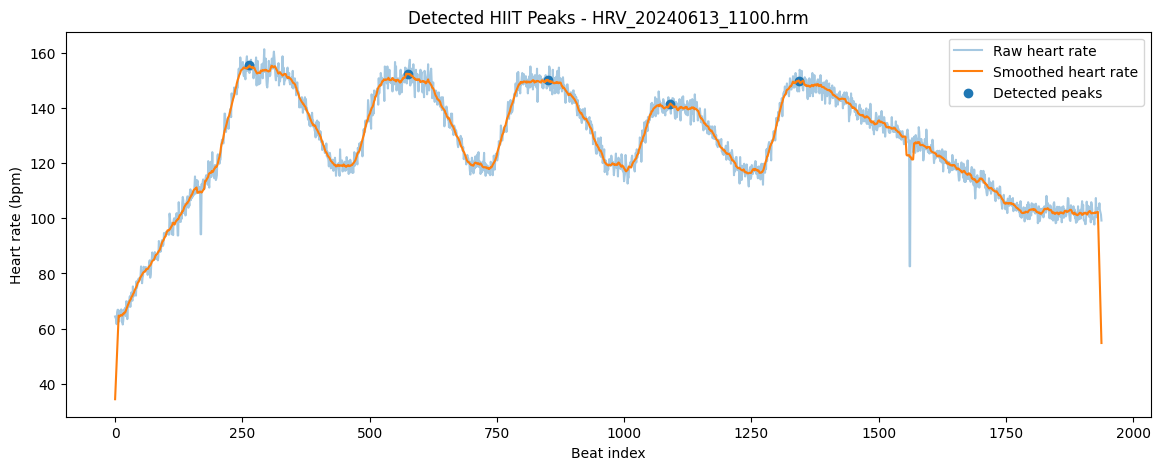

In [ ]:
import matplotlib.pyplot as plt

smoothed_hr = peak_result["smoothed_heart_rate"]
peaks = peak_result["peaks"]

plt.figure(figsize=(14, 5))
plt.plot(heart_rate, alpha=0.4, label="Raw heart rate")
plt.plot(smoothed_hr, label="Smoothed heart rate")
plt.scatter(peaks, [smoothed_hr[p] for p in peaks], marker="o", label="Detected peaks")

plt.title(f"Detected HIIT Peaks - {parsed['file_name']}")
plt.xlabel("Beat index")
plt.ylabel("Heart rate (bpm)")
plt.legend()

plt.show()

# 8. Target Heart Rate Zone

We calculate the target heart rate zone based on the training week.

In [ ]:
%%writefile /content/hiit_project/src/target_zone.py

from typing import Dict
from datetime import datetime


def parse_date(date_str: str) -> datetime:
    """
    Convert a string in YYYYMMDD format to a datetime object.
    """
    return datetime.strptime(date_str, "%Y%m%d")


def compute_training_week(session_date: str, first_session_date: str) -> int:
    """
    Compute the training week for a session using the known program start date.
    """
    session_dt = parse_date(session_date)
    start_dt = parse_date(first_session_date)

    delta_days = (session_dt - start_dt).days
    week = delta_days // 7 + 1

    return week


def get_target_zone(max_hr: int, week: int) -> Dict[str, float]:
    """
    Compute target heart rate zone based on training week.
    """
    if week <= 2:
        low, high = 0.80, 0.85
    elif week <= 6:
        low, high = 0.85, 0.90
    else:
        low, high = 0.90, 0.95

    return {
        "low": low * max_hr,
        "high": high * max_hr
    }

Writing /content/hiit_project/src/target_zone.py


In [ ]:
# Get valid sessions only
valid_sessions = validation_df[validation_df["is_valid"] == True]

# Extract dates from metadata
dates = []

for file_path in valid_sessions["file_path"]:
    parsed = read_hrm_file(file_path)
    date = parsed["metadata"].get("Date")

    if date:
        dates.append(date)

print("Sample dates:", dates[:5])

Sample dates: ['20240613', '20240624', '20240411', '20240509', '20240425']


In [ ]:
from target_zone import compute_training_week, get_target_zone

# Example
sample_date = parsed["metadata"].get("Date")

sample_week = compute_training_week(
    session_date=sample_date,
    first_session_date=FIRST_SESSION_DATE
)

sample_max_hr = PATIENT_HRMAX

zone = get_target_zone(
    max_hr=sample_max_hr,
    week=sample_week
)

print("Date:", sample_date)
print("Week:", sample_week)
print("Max HR:", sample_max_hr)
print("Target zone:", zone)

Date: 20240502
Week: 4
Max HR: 165
Target zone: {'low': 140.25, 'high': 148.5}


# 9. Session Scoring

We score each session based on how many detected intervals reach the target heart rate zone.

In [ ]:
%%writefile /content/hiit_project/src/scoring.py

from typing import List, Dict, Any


def score_session(
    peak_heart_rates: List[float],
    target_zone: Dict[str, float]
) -> Dict[str, Any]:
    """
    Score a HIIT session based on how many detected peaks fall within the target heart rate zone.

    Parameters
    ----------
    peak_heart_rates : List[float]
        Heart rate values at detected HIIT peaks.
    target_zone : Dict[str, float]
        Dictionary containing lower and upper bounds of the target zone.

    Returns
    -------
    Dict[str, Any]
        Session score and per-peak pass/fail results.
    """
    low = target_zone["low"]
    high = target_zone["high"]

    interval_results = []

    for i, peak_hr in enumerate(peak_heart_rates, start=1):
        reached_target = low <= peak_hr <= high

        interval_results.append({
            "interval_number": i,
            "peak_heart_rate": peak_hr,
            "reached_target": reached_target
        })

    score = sum(result["reached_target"] for result in interval_results)

    return {
        "score": int(score),
        "max_score": len(peak_heart_rates),
        "interval_results": interval_results
    }

Writing /content/hiit_project/src/scoring.py


In [ ]:
from scoring import score_session

scoring_result = score_session(
    peak_heart_rates=peak_result["peak_heart_rates"],
    target_zone=zone
)

print("Score:", scoring_result["score"], "/", scoring_result["max_score"])
print("Interval results:")

for result in scoring_result["interval_results"]:
    print(result)

Score: 1 / 5
Interval results:
{'interval_number': 1, 'peak_heart_rate': 155.40371842000906, 'reached_target': False}
{'interval_number': 2, 'peak_heart_rate': 152.43306728348415, 'reached_target': False}
{'interval_number': 3, 'peak_heart_rate': 150.21185865630736, 'reached_target': False}
{'interval_number': 4, 'peak_heart_rate': 141.5982728275621, 'reached_target': True}
{'interval_number': 5, 'peak_heart_rate': 149.94706775319162, 'reached_target': False}


# 10. Batch Processing

We apply the full pipeline to all HRM files to generate session-level results.

In [ ]:
import sys
import importlib

# Make sure the src directory is available
sys.path.append("/content/hiit_project/src")

# Reload the updated target_zone module
import target_zone
importlib.reload(target_zone)

from hrm_parser import read_hrm_file
from validation import validate_session
from rr_cleaning import clean_rr_intervals, rr_to_heart_rate
from interval_detection import detect_hiit_peaks
from target_zone import compute_training_week, get_target_zone
from scoring import score_session

# Process all HRM files
batch_results = []

for file_path in hrm_files:
    parsed_session = read_hrm_file(file_path)
    validation_result = validate_session(parsed_session)

    result = {
        "file_name": parsed_session["file_name"],
        "file_path": parsed_session["file_path"],
        "date": parsed_session["metadata"].get("Date"),
        "start_time": parsed_session["metadata"].get("StartTime"),
        "max_hr": PATIENT_HRMAX,
        "rr_count_raw": parsed_session["rr_count"],
        "is_valid": validation_result["is_valid"],
        "reason": validation_result["reason"],
        "week": None,
        "target_zone_low": None,
        "target_zone_high": None,
        "num_peaks_detected": None,
        "score": None,
        "max_score": None,
        "cleaned_rr_count": None,
        "removed_rr_count": None,
        "corrected_missed_beats": None,
    }

    # Skip invalid sessions but keep them in the final output
    if not validation_result["is_valid"]:
        batch_results.append(result)
        continue

    # Clean RR intervals and convert to heart rate
    cleaning_result = clean_rr_intervals(parsed_session["rr_intervals"])
    heart_rate = rr_to_heart_rate(cleaning_result["cleaned_rr"])

    # Detect HIIT peaks
    peak_result = detect_hiit_peaks(heart_rate)

    # Calculate training week and target heart rate zone
    session_date = parsed_session["metadata"].get("Date")

    week = compute_training_week(
        session_date=session_date,
        first_session_date=FIRST_SESSION_DATE
    )

    max_hr = PATIENT_HRMAX

    zone = get_target_zone(
        max_hr=max_hr,
        week=week
    )

    # Score the session
    scoring_result = score_session(
        peak_heart_rates=peak_result["peak_heart_rates"],
        target_zone=zone
    )

    # Store final result
    result.update({
        "week": week,
        "target_zone_low": zone["low"],
        "target_zone_high": zone["high"],
        "num_peaks_detected": peak_result["num_peaks_detected"],
        "score": scoring_result["score"],
        "max_score": scoring_result["max_score"],
        "cleaned_rr_count": cleaning_result["cleaned_count"],
        "removed_rr_count": cleaning_result["removed_count"],
        "corrected_missed_beats": cleaning_result["corrected_missed_beats"],
    })

    batch_results.append(result)

print(f"Processed files: {len(batch_results)}")

Processed files: 31


In [ ]:
batch_df = pd.DataFrame(batch_results)

batch_df.head(10)

,file_name,file_path,date,start_time,max_hr,rr_count_raw,is_valid,reason,week,target_zone_low,target_zone_high,num_peaks_detected,score,max_score,cleaned_rr_count,removed_rr_count,corrected_missed_beats
0,HRV_20240613_1100.hrm,/content/hiit_project/data/raw/files/package_f...,20240613,11:00:00.0,165,1940,True,valid,10.0,148.50,156.75,5.0,4.0,5.0,1939.0,4.0,3.0
1,HRV_20240624_1145.hrm,/content/hiit_project/data/raw/files/package_f...,20240624,11:45:00.0,165,1846,True,valid,12.0,148.50,156.75,5.0,2.0,5.0,1846.0,0.0,0.0
2,HRV_20240411_0815.hrm,/content/hiit_project/data/raw/files/package_f...,20240411,08:15:00.0,165,1854,True,valid,1.0,132.00,140.25,5.0,2.0,5.0,1854.0,0.0,0.0
3,HRV_20240509_1130.hrm,/content/hiit_project/data/raw/files/package_f...,20240509,11:30:00.0,165,1759,True,valid,5.0,140.25,148.50,5.0,3.0,5.0,1757.0,2.0,0.0
4,HRV_20240411_0912.hrm,/content/hiit_project/data/raw/files/package_f...,20240411,09:12:00.0,165,0,False,invalid_no_rr_data,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,HRV_20240425_0830.hrm,/content/hiit_project/data/raw/files/package_f...,20240425,08:30:00.0,165,1929,True,valid,3.0,140.25,148.50,5.0,3.0,5.0,1929.0,0.0,0.0
6,HRV_20240527_1115.hrm,/content/hiit_project/data/raw/files/package_f...,20240527,11:15:00.0,165,1866,True,valid,8.0,148.50,156.75,5.0,3.0,5.0,1866.0,0.0,0.0
7,HRV_20240617_1145.hrm,/content/hiit_project/data/raw/files/package_f...,20240617,11:45:00.0,165,1816,True,valid,11.0,148.50,156.75,5.0,3.0,5.0,1816.0,0.0,0.0
8,HRV_20240603_1030.hrm,/content/hiit_project/data/raw/files/package_f...,20240603,10:30:00.0,165,2062,True,valid,9.0,148.50,156.75,5.0,2.0,5.0,2059.0,3.0,0.0
9,HRV_20240610_0845.hrm,/content/hiit_project/data/raw/files/package_f...,20240610,08:45:00.0,165,1822,True,valid,10.0,148.50,156.75,5.0,5.0,5.0,1824.0,0.0,2.0


In [ ]:
print("Validation summary:")
print(batch_df["reason"].value_counts())

print("\nScore distribution for valid sessions:")
print(batch_df[batch_df["is_valid"] == True]["score"].value_counts().sort_index())

Validation summary:
reason
valid                 24
invalid_no_rr_data     4
invalid_too_short      3
Name: count, dtype: int64

Score distribution for valid sessions:
score
1.0    2
2.0    6
3.0    8
4.0    6
5.0    2
Name: count, dtype: int64


# 11. Output Generation

We save the final session scoring results as a structured CSV file.

In [ ]:
# Save final batch results to CSV

output_csv_path = os.path.join(OUTPUT_DIR, "hiit_session_scores.csv")

batch_df.to_csv(output_csv_path, index=False)

print(f"Output saved to: {output_csv_path}")

Output saved to: /content/hiit_project/outputs/hiit_session_scores.csv


In [ ]:
from google.colab import files

files.download(output_csv_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Ensure dataframe exists
import pandas as pd

df = pd.DataFrame(batch_results)

# Create submission CSV
submission_df = df[[
    "file_name",
    "date",
    "week",
    "score",
    "is_valid",
    "reason"
]]

submission_path = "/content/hiit_project/outputs/hiit_submission.csv"

submission_df.to_csv(submission_path, index=False)

print("Submission CSV created!")

# Download
from google.colab import files
files.download(submission_path)

Submission CSV created!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 12. Summary and Key Findings

This section summarizes the number of valid and invalid sessions and the distribution of final HIIT scores.

In [ ]:
print("Total files:", len(batch_df))
print("Valid sessions:", batch_df["is_valid"].sum())
print("Invalid sessions:", (~batch_df["is_valid"]).sum())

print("\nInvalid reasons:")
print(batch_df["reason"].value_counts())

print("\nScore distribution:")
print(batch_df[batch_df["is_valid"] == True]["score"].value_counts().sort_index())

Total files: 31
Valid sessions: 24
Invalid sessions: 7

Invalid reasons:
reason
valid                 24
invalid_no_rr_data     4
invalid_too_short      3
Name: count, dtype: int64

Score distribution:
score
1.0    2
2.0    6
3.0    8
4.0    6
5.0    2
Name: count, dtype: int64


# 13. Project Documentation

In [ ]:
readme_content = """# HIIT Session Scoring Project

## Overview
This project processes HRM files and scores HIIT training sessions based on whether the participant reaches target heart rate zones during high-intensity intervals.

The solution is implemented as a modular and reusable pipeline that can be applied to new HRM datasets without modification.

---

## Key Results
- Total sessions: 31
- Valid sessions: 24
- Invalid sessions: 7

Invalid sessions:
- 4 sessions with no RR data
- 3 sessions that were too short

Score distribution (valid sessions):
- Score 1: 2
- Score 2: 6
- Score 3: 8
- Score 4: 6
- Score 5: 2

---

## Method Summary
Pipeline steps:

Parse → Validate → Clean → Convert → Detect Peaks → Compute Zone → Score

- Extract RR intervals from HRM files
- Identify and exclude invalid sessions
- Handle artifacts (implausible values and missed beats)
- Convert RR intervals to heart rate
- Detect five high-intensity intervals
- Score sessions based on target heart rate zones

---

## Output
The project produces CSV files containing both results and diagnostic information.

Main fields:
- file_name
- date
- week
- score
- is_valid
- reason

Additional diagnostic fields:
- file_path
- max_hr
- rr_count_raw
- cleaned_rr_count
- removed_rr_count
- corrected_missed_beats
- target_zone_low
- target_zone_high
- num_peaks_detected

---

## How to Run
1. Place HRM files in the data directory
2. Open the notebook
3. Run all cells

Outputs will be saved in the `outputs/` folder.

---

## Project Structure
- hiit_session_scoring_pipeline.ipynb → main pipeline
- src/ → modular implementation
- outputs/ → CSV results
- reports/ → project report

---

## Report
A detailed explanation is available in:

reports/hiit_report.md
"""

with open("/content/hiit_project/README.md", "w") as f:
    f.write(readme_content)

print("README saved successfully!")

README saved successfully!
